<a href="https://colab.research.google.com/github/Hajer5503/Esprit-PI-4DS5-AgriSmart/blob/feature%2Firrigation-rl/modules/irrigation_rl/notebooks/Layer2_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Irrigation Optimization — Layer 2: RL Control Agent
## Context

Layer 1 answers: *"What will happen tomorrow?"*
→ Predicts `sm_root(t+1)` and `ET₀(t+1)` from weather + soil sensors.

Layer 2 answers: *"What should we do about it?"*
→ Learns an optimal irrigation policy from those predictions.

---

## Business Objective

Train a Reinforcement Learning agent that:
- **Maintains soil moisture in the optimal band** (avoids crop stress)
- **Minimises water waste** (no over-irrigation)
- **Adapts to growth stage** (Kc varies across the wheat season)
- **Operates autonomously** with decision latency < 5 seconds

---

## Why Reinforcement Learning?

A rule-based scheduler (irrigate = ETc − precip) is static — it cannot:
- Learn from past seasons
- Adapt to soil memory effects (previous irrigation still draining)
- Balance competing objectives (yield vs water cost)
- Handle partial observability (sensors may be noisy)

RL learns a **policy** π(s) → a that maximises long-term cumulative reward,
not just the immediate best action. Over multiple seasons it discovers
irrigation strategies that no hand-crafted rule can match.

---

## MDP Formulation

We model irrigation scheduling as a **Markov Decision Process (MDP)**:

| Component | Definition |
|-----------|-----------|
| **State S** | `[ET₀, precip, sm_shallow, sm_deep, Kc, growth_stage, day_of_season]` |
| **Action A** | Discrete: `{0, 5, 10, 15, 20}` mm/day |
| **Reward R** | Multi-objective: stress penalty + excess penalty + water cost |
| **Transition** | FAO-56 soil water balance: SM(t+1) = SM(t) + precip + irr − ETc |
| **Episode** | One complete wheat season (sowing → harvest, ~228 days) |

---

## Connection to Layer 1

```
Layer 1 Output               Layer 2 Input (State)
─────────────────────────    ──────────────────────────────────
sm_root(t+1) predicted   →   sm_shallow, sm_deep  (soil state)
ET₀(t+1) predicted       →   ET₀                 (atmospheric demand)
                             precip, Kc, growth_stage, day_of_season
```

Layer 1 predictions replace raw sensor readings in the state vector,
making the RL agent forward-looking rather than reactive.

---

## Agronomic Constants — FAO-56 Wheat (Tunisia)

| Parameter | Symbol | Value | Meaning |
|-----------|--------|-------|---------|
| Field Capacity | FC | 0.28 | Max water soil can hold (vol/vol) |
| Wilting Point | WP | 0.12 | Plant can no longer extract water |
| Depletion fraction | p | 0.55 | FAO-56 wheat stress threshold |
| Readily Available Water | RAW | p×(FC−WP) = 0.088 | Below → crop stress |
| Optimal lower bound | SM_LOW | WP + RAW = 0.208 | Stress threshold |
| Optimal upper bound | SM_HIGH | FC = 0.28 | Drainage / runoff above this |

---


## 1.Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from collections import deque
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings, random
import joblib, json

warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load dataset

In [2]:
def load_dataset(path):
    df = pd.read_csv(path, sep=';', parse_dates=['date'], dayfirst=True)
    df = df.sort_values('date').reset_index(drop=True)

    for col in ['sm_shallow', 'sm_deep', 'sm_root']:
        if df[col].max() > 1.0:
            df[col] /= 100.0

    def growth_stage(d):
        if   d <= 20:  return 0
        elif d <= 50:  return 1
        elif d <= 100: return 2
        elif d <= 175: return 3
        else:          return 4

    df['growth_stage'] = df['day_of_season'].apply(growth_stage)
    df['season_id'] = (df['day_of_season'].diff() < -50).cumsum()
    return df

df = load_dataset('rl_dataset_final.csv')
all_seasons = [g.reset_index(drop=True)
               for _, g in df.groupby('season_id') if len(g) >= 80]
train_seasons = all_seasons[:-1]
test_seasons  = all_seasons[-1:]

print(f"Dataset: {len(df)} rows | {len(all_seasons)} seasons")
print(f"Train: {len(train_seasons)} | Test: {len(test_seasons)}")

Dataset: 772 rows | 4 seasons
Train: 3 | Test: 1


In [ ]:
# ── Load trained Layer 1 models ───────────────────────────────────────────────
l1_sm  = joblib.load('layer1_model_sm_root.pkl')
l1_et0 = joblib.load('layer1_model_et0.pkl')

with open('layer1_feature_cols.json') as f:
    L1_FEATURES = json.load(f)

print("✅ Layer 1 models loaded")
print(f"   sm_root model  : {type(l1_sm).__name__}")
print(f"   ET₀ model      : {type(l1_et0).__name__}")
print(f"   Features       : {len(L1_FEATURES)} columns")

# ── Build lag/rolling features on df (same pipeline as Layer 1) ──────────────
LAG_COLS = ['sm_root','sm_shallow','sm_deep','et0_mm','etc_mm',
            'precip_mm','temp_c','irrigation_mm']
for col in LAG_COLS:
    for lag in [1, 3, 7]:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

ROLL_COLS = {
    'sm_root':['mean','std'], 'et0_mm':['mean','sum'],
    'precip_mm':['sum'], 'temp_c':['mean'], 'irrigation_mm':['sum'],
}
for col, funcs in ROLL_COLS.items():
    for func in funcs:
        df[f'{col}_roll7_{func}'] = df[col].rolling(7, min_periods=1).agg(func)

df['sin_doy'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['cos_doy'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
df['month']   = df['date'].dt.month

# ── Run inference — generate predictions for every day ───────────────────────
df_l1 = df.dropna(subset=L1_FEATURES).copy()
df_l1.reset_index(drop=True, inplace=True)

X_all = df_l1[L1_FEATURES].values

df_l1['pred_sm_root'] = l1_sm.predict(X_all)
df_l1['pred_et0_mm']  = (0.30 * df_l1['et0_mm'].values +
                          0.70 * l1_et0.predict(X_all))

print(f"\nLayer 1 predictions generated for {len(df_l1)} days")
print(f"  pred_sm_root : [{df_l1['pred_sm_root'].min():.4f}, "
      f"{df_l1['pred_sm_root'].max():.4f}]")
print(f"  pred_et0_mm  : [{df_l1['pred_et0_mm'].min():.4f}, "
      f"{df_l1['pred_et0_mm'].max():.4f}]")
print("✅ Layer 1 → Layer 2 handoff complete")

## 3. MDP Visualisation — State, Action, Reward

Seasons available for training: 4
  Season 0: 2022-11-16 → 2023-06-15  (212 days)
  Season 1: 2023-11-01 → 2024-06-15  (228 days)
  Season 2: 2024-11-01 → 2025-06-15  (227 days)
  Season 3: 2025-11-01 → 2026-02-13  (105 days)


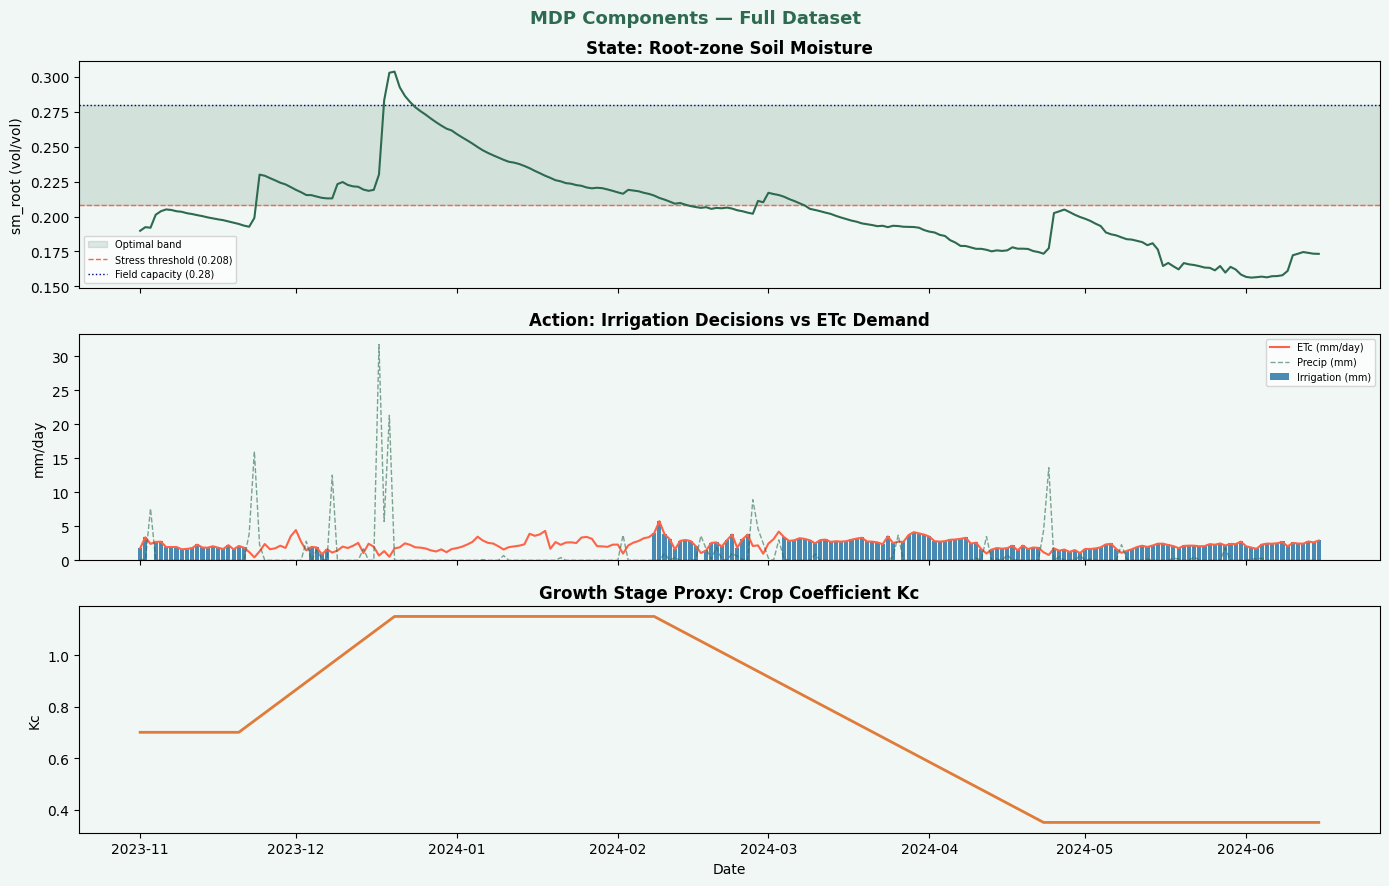

In [3]:
# Identify seasons
df['season_id'] = (df['day_of_season'].diff() < -50).cumsum()
seasons = [g.reset_index(drop=True) for _,g in df.groupby('season_id') if len(g)>=80]

print(f"Seasons available for training: {len(seasons)}")
for i,s in enumerate(seasons):
    print(f"  Season {i}: {s['date'].iloc[0].date()} → {s['date'].iloc[-1].date()}  ({len(s)} days)")

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, facecolor='#f0f7f4')
fig.suptitle('MDP Components — Full Dataset', fontsize=13,
             fontweight='bold', color='#2d6a4f')

s = seasons[1]  # Show season 1 as example

axes[0].axhspan(0.208, 0.28, alpha=0.15, color='#2d6a4f', label='Optimal band')
axes[0].axhline(0.208, color='tomato', lw=1, ls='--', label='Stress threshold (0.208)')
axes[0].axhline(0.28,  color='navy',   lw=1, ls=':', label='Field capacity (0.28)')
axes[0].plot(s['date'], s['sm_root'], color='#2d6a4f', lw=1.5)
axes[0].set_ylabel('sm_root (vol/vol)'); axes[0].legend(fontsize=7)
axes[0].set_title('State: Root-zone Soil Moisture', fontweight='bold')
axes[0].set_facecolor('#f0f7f4')

axes[1].bar(s['date'], s['irrigation_mm'], color='#1d6fa4', alpha=0.8, label='Irrigation (mm)')
axes[1].plot(s['date'], s['etc_mm'], color='tomato', lw=1.5, label='ETc (mm/day)')
axes[1].plot(s['date'], s['precip_mm'], color='#2d6a4f', lw=1, ls='--', alpha=0.6, label='Precip (mm)')
axes[1].set_ylabel('mm/day'); axes[1].legend(fontsize=7)
axes[1].set_title('Action: Irrigation Decisions vs ETc Demand', fontweight='bold')
axes[1].set_facecolor('#f0f7f4')

axes[2].plot(s['date'], s['kc'], color='#e07b39', lw=2)
axes[2].set_ylabel('Kc'); axes[2].set_xlabel('Date')
axes[2].set_title('Growth Stage Proxy: Crop Coefficient Kc', fontweight='bold')
axes[2].set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('mdp_overview.png', dpi=130, bbox_inches='tight')
plt.show()

## Reward Function Design

$$R_t = \underbrace{-3 \cdot \text{stress}}_\text{under-irrigation} + \underbrace{+2 \cdot \mathbf{1}[SM \in \text{opt}]}_\text{optimality bonus} - \underbrace{1 \cdot \text{excess}}_\text{over-irrigation} - \underbrace{0.05 \cdot I_t}_\text{water cost}$$

| Condition | Contribution | Rationale |
|-----------|-------------|-----------|
| `sm < 0.208` | −3 × proportional stress | Crop stress is the worst outcome |
| `0.208 ≤ sm ≤ 0.28` | +2 | Reward staying in optimal band |
| `sm > 0.28` | −1 × excess | Drainage wastes water and nutrients |
| Any irrigation | −0.05 × mm | Encourages water efficiency |

The asymmetry (stress penalty 3× > excess penalty 1×) reflects agronomic reality:
under-irrigation permanently damages yield while over-irrigation is recoverable.

## 4. Growth Stage Labels

FAO-56 piecewise wheat growth stages derived from `day_of_season`.

In [4]:
def growth_stage(d):
    """FAO-56 wheat growth stages."""
    if   d <= 20:  return 0   # Initial
    elif d <= 50:  return 1   # Development
    elif d <= 100: return 2   # Mid-season  (peak Kc)
    elif d <= 175: return 3   # Late-season (Kc declining)
    else:          return 4   # Maturity / End

df['growth_stage'] = df['day_of_season'].apply(growth_stage)

STAGE_NAMES = {0:'Initial', 1:'Development', 2:'Mid-season',
               3:'Late-season', 4:'Maturity'}

print("Growth stage distribution:")
for g, cnt in df['growth_stage'].value_counts().sort_index().items():
    print(f"  {g} – {STAGE_NAMES[g]:<15} : {cnt:4d} days  ({cnt/len(df)*100:.1f}%)")

Growth stage distribution:
  0 – Initial         :   65 days  (8.4%)
  1 – Development     :  120 days  (15.5%)
  2 – Mid-season      :  200 days  (25.9%)
  3 – Late-season     :  230 days  (29.8%)
  4 – Maturity        :  157 days  (20.3%)


## 5. Season Split

Each crop season = one RL episode. Train on seasons 0-2, test on season 3.

In [5]:
df['season_id'] = (df['day_of_season'].diff() < -50).cumsum()

all_seasons = [g.reset_index(drop=True)
               for _, g in df_l1.groupby('season_id') if len(g) >= 80]
train_seasons = all_seasons[:-1]   # Seasons 0, 1, 2
test_seasons  = all_seasons[-1:]   # Season 3

print(f"Total seasons : {len(all_seasons)}")
print(f"Train         : {len(train_seasons)}")
print(f"Test          : {len(test_seasons)}")
print()
for i, s in enumerate(all_seasons):
    split = "TRAIN" if i < len(train_seasons) else "TEST"
    print(f"  Season {i} [{split}]: {s['date'].iloc[0].date()} → "
          f"{s['date'].iloc[-1].date()}  ({len(s)} days)")

Total seasons : 4
Train         : 3
Test          : 1

  Season 0 [TRAIN]: 2022-11-16 → 2023-06-15  (212 days)
  Season 1 [TRAIN]: 2023-11-01 → 2024-06-15  (228 days)
  Season 2 [TRAIN]: 2024-11-01 → 2025-06-15  (227 days)
  Season 3 [TEST]: 2025-11-01 → 2026-02-13  (105 days)


## 6. State Feature Analysis

In [6]:
# MDP state: [et0, precip, sm_shallow, sm_deep, kc, growth_stage, day_of_season]
STATE_COLS = ['et0_mm', 'precip_mm', 'sm_shallow', 'sm_deep',
              'kc', 'growth_stage', 'day_of_season']

print("State feature statistics across all seasons:")
print(f"  {'Feature':<20} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8}")
print("  " + "-"*48)
for col in STATE_COLS:
    print(f"  {col:<20} {df[col].min():>8.3f} {df[col].max():>8.3f} "
          f"{df[col].mean():>8.3f} {df[col].std():>8.3f}")

# Soil moisture bounds check
FC, WP, RAW = 0.28, 0.12, 0.55*(0.28-0.12)
SM_LOW = WP + RAW   # 0.208
print(f"\nSoil moisture analysis:")
print(f"  Days below stress threshold ({SM_LOW:.3f}): "
      f"{(df['sm_root'] < SM_LOW).sum()} ({(df['sm_root']<SM_LOW).mean()*100:.1f}%)")
print(f"  Days in optimal band        : "
      f"{((df['sm_root']>=SM_LOW)&(df['sm_root']<=FC)).sum()} "
      f"({((df['sm_root']>=SM_LOW)&(df['sm_root']<=FC)).mean()*100:.1f}%)")
print(f"  Days above field capacity   : "
      f"{(df['sm_root'] > FC).sum()} ({(df['sm_root']>FC).mean()*100:.1f}%)")

State feature statistics across all seasons:
  Feature                   Min      Max     Mean      Std
  ------------------------------------------------
  et0_mm                  0.370    8.670    3.286    1.685
  precip_mm               0.000   31.700    0.826    3.069
  sm_shallow              0.138    0.342    0.188    0.031
  sm_deep                 0.168    0.273    0.213    0.017
  kc                      0.350    1.150    0.797    0.310
  growth_stage            0.000    4.000    2.381    1.209
  day_of_season           1.000  228.000  107.911   64.695

Soil moisture analysis:
  Days below stress threshold (0.208): 563 (72.9%)
  Days in optimal band        : 203 (26.3%)
  Days above field capacity   : 6 (0.8%)


## 7. Irrigation Pattern Analysis

## 8. `IrrigationEnv` — Custom RL Environment

### Reward Function

$$R_t = \begin{cases}
-3 \times \frac{SM_{LOW} - sm}{RAW} & \text{if } sm < SM_{LOW} \text{ (stress)} \\
+2 & \text{if } SM_{LOW} \leq sm \leq FC \text{ (optimal)} \\
-1 \times \frac{sm - FC}{TAW} & \text{if } sm > FC \text{ (excess)}
\end{cases} - 0.05 \times I_t$$

### Soil Water Balance (FAO-56)

$$SM(t+1) = SM(t) + (P_t + I_t - ET_{c,t}) \times \delta$$

where δ = 0.006 converts mm/day flux to vol/vol change in root zone.

In [8]:
# ── FAO-56 Wheat Parameters (Tunisia) ────────────────────────────────────────
FC   = 0.28    # Field Capacity (vol/vol)
WP   = 0.12    # Wilting Point  (vol/vol)
TAW  = FC - WP # Total Available Water = 0.16
p    = 0.55    # Depletion fraction (FAO-56 wheat)
RAW  = p * TAW # Readily Available Water = 0.088

SM_OPT_LOW  = WP + RAW  # 0.208  ← stress threshold
SM_OPT_HIGH = FC         # 0.28   ← drainage threshold

# ── Action Space ──────────────────────────────────────────────────────────────
ACTIONS   = [0, 5, 10, 15, 20]   # mm/day
N_ACTIONS = len(ACTIONS)

print(f"Soil parameters  : FC={FC} | WP={WP} | TAW={TAW} | RAW={RAW:.3f}")
print(f"Optimal SM band  : [{SM_OPT_LOW:.3f}, {SM_OPT_HIGH:.3f}]")
print(f"Action space     : {ACTIONS} mm/day  ({N_ACTIONS} discrete actions)")

Soil parameters  : FC=0.28 | WP=0.12 | TAW=0.16000000000000003 | RAW=0.088
Optimal SM band  : [0.208, 0.280]
Action space     : [0, 5, 10, 15, 20] mm/day  (5 discrete actions)


In [9]:
class IrrigationEnv:
    """
    Custom Gym-style RL environment for irrigation scheduling.

    Observation space : R^7  (continuous)
    Action space      : Discrete(5) → {0, 5, 10, 15, 20} mm/day
    Episode           : One wheat season (sowing → harvest)
    """

    N_STATE   = 7
    N_ACTIONS = N_ACTIONS

    def __init__(self, seasons: list):
        """
        Args:
            seasons: list of DataFrames, one per crop season.
                     Each represents one RL episode.
        """
        self.seasons  = seasons
        self.ep_idx   = 0
        self.df       = None
        self.step_idx = 0
        self.done     = False

    # ── State builder ─────────────────────────────────────────────────────────
    def _state(self, row) -> np.ndarray:
        """
        Construct 7-dim state vector from a dataset row.
        Growth stage and day_of_season normalised to [0, 1].
        """
        return np.array([
            row['et0_mm'],
            row['precip_mm'],
            row['sm_shallow'],
            row['sm_deep'],
            row['kc'],
            row['growth_stage'] / 4.0,        # normalise 0–4 → 0–1
            row['day_of_season'] / 228.0,      # normalise 0–228 → 0–1
        ], dtype=np.float32)

    # ── Reward function ───────────────────────────────────────────────────────
    @staticmethod
    def _reward(sm_next: float, irr_mm: float) -> float:
        """Multi-objective agronomic reward."""
        if sm_next < SM_OPT_LOW:
            stress = (SM_OPT_LOW - sm_next) / RAW
            r = -3.0 * min(stress, 1.0)       # stress penalty (worst outcome)
        elif sm_next > FC:
            excess = (sm_next - FC) / TAW
            r = -1.0 * min(excess, 1.0)        # over-irrigation penalty
        else:
            r = +2.0                            # optimal band bonus
        r -= 0.05 * irr_mm                      # water-use cost
        return float(r)

    # ── Reset ─────────────────────────────────────────────────────────────────
    def reset(self, season_idx: int | None = None) -> np.ndarray:
        """Start a new episode (new season). Returns initial state."""
        if season_idx is not None:
            self.ep_idx = season_idx % len(self.seasons)
        self.df       = self.seasons[self.ep_idx].reset_index(drop=True)
        self.step_idx = 0
        self.done     = False
        self.ep_idx   = (self.ep_idx + 1) % len(self.seasons)
        return self._state(self.df.iloc[0])

    # ── Step ──────────────────────────────────────────────────────────────────
    def step(self, action_idx: int):
        """
        Execute one irrigation action.

        Args:
            action_idx: index into ACTIONS list (0–4)

        Returns:
            next_state : np.ndarray (7,)
            reward     : float
            done       : bool
            info       : dict with agronomic details
        """
        assert not self.done, "Episode ended — call reset() first"

        row    = self.df.iloc[self.step_idx]
        irr_mm = ACTIONS[action_idx]

        # Soil water balance (FAO-56)
        # depth_factor converts mm/day → vol/vol change in root zone
        depth_factor = 0.006
        sm_next = float(np.clip(
            row['sm_root'] + (row['precip_mm'] + irr_mm - row['etc_mm']) * depth_factor,
            WP, FC + 0.05
        ))

        reward = self._reward(sm_next, irr_mm)

        self.step_idx += 1
        self.done = (self.step_idx >= len(self.df))
        next_state = (np.zeros(self.N_STATE, dtype=np.float32)
                      if self.done
                      else self._state(self.df.iloc[self.step_idx]))

        info = {
            'date':     row['date'],
            'sm_root':  sm_next,
            'irr_mm':   irr_mm,
            'etc_mm':   row['etc_mm'],
            'precip':   row['precip_mm'],
            'in_opt':   SM_OPT_LOW <= sm_next <= SM_OPT_HIGH,
        }
        return next_state, reward, self.done, info


# ── Sanity test ───────────────────────────────────────────────────────────────
env = IrrigationEnv(train_seasons)
s0  = env.reset(season_idx=0)

print(f"State shape   : {s0.shape}")
print(f"State values  : {np.round(s0, 4)}")
print(f"State meaning : [ET₀, precip, sm_shallow, sm_deep, Kc, growth_stage_n, day_n]")

s1, r, done, info = env.step(2)  # action 2 = 10mm
print(f"\nAfter 10mm irrigation:")
print(f"  sm_root  : {info['sm_root']:.4f}  ({'in optimal band' if info['in_opt'] else 'outside band'})")
print(f"  reward   : {r:.3f}")
print("✅ IrrigationEnv OK")

State shape   : (7,)
State values  : [2.53   0.3    0.1787 0.23   0.7    0.     0.0702]
State meaning : [ET₀, precip, sm_shallow, sm_deep, Kc, growth_stage_n, day_n]

After 10mm irrigation:
  sm_root  : 0.2504  (in optimal band)
  reward   : 1.500
✅ IrrigationEnv OK


## 9. Rule-Based Baseline Policy

The benchmark to beat: irrigate the ETc deficit, snapped to the action space.

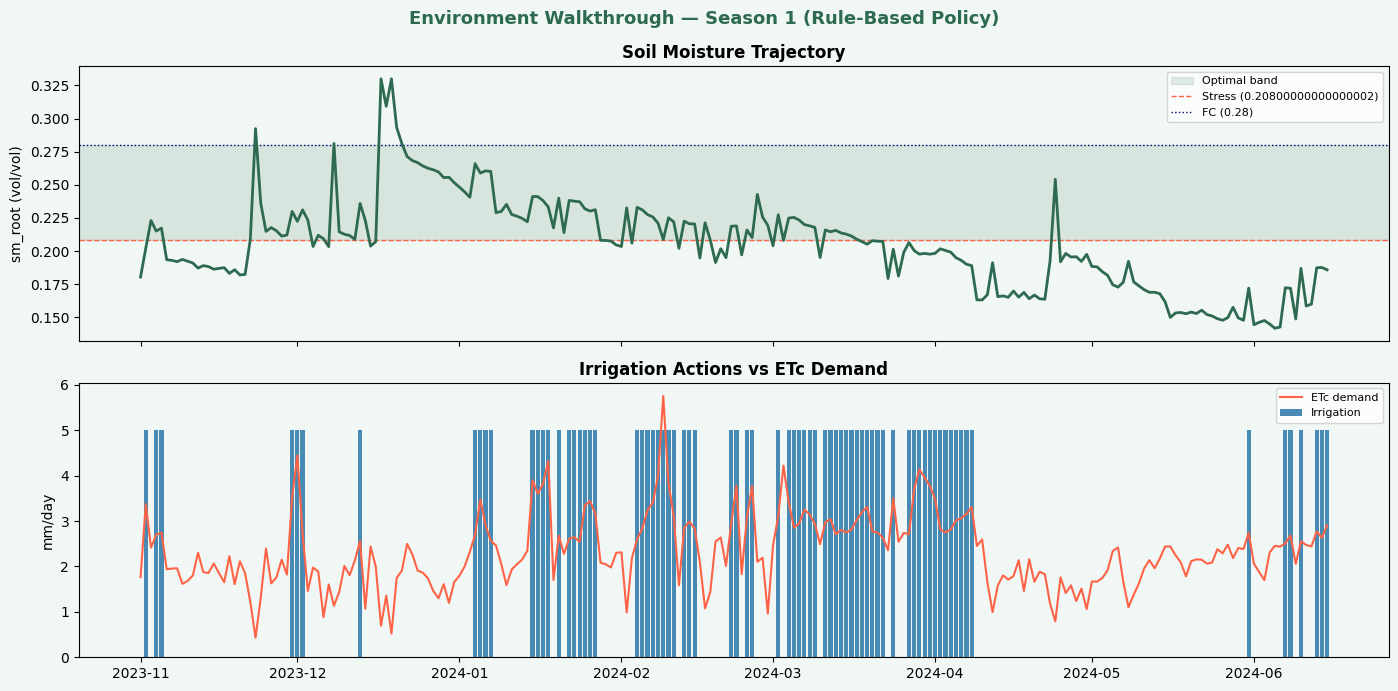

Rule-based Season 1 stats:
  Total irrigation : 385.0 mm
  Total reward     : 60.79
  Optimal days     : 98 (43.0%)
  Stress days      : 130 (57.0%)


In [10]:
def rule_based_action(row) -> int:
    """
    Rule-based scheduler: irrigate to cover ETc - precip deficit.
    Snaps the continuous need to the nearest discrete action.
    """
    need  = max(0.0, row['etc_mm'] - row['precip_mm'])
    return int(np.argmin([abs(ACTIONS[a] - need) for a in range(N_ACTIONS)]))


def rollout(env, season_idx=0, policy='rule', agent=None) -> pd.DataFrame:
    """Run one full season and collect daily records."""
    state = env.reset(season_idx=season_idx)
    records = []

    while True:
        step = min(env.step_idx, len(env.df)-1)
        row  = env.df.iloc[step]

        if policy == 'rule':
            action = rule_based_action(row)
        elif policy == 'rl' and agent is not None:
            action = agent.act(state, greedy=True)
        else:
            action = 2  # default: 10mm

        state, reward, done, info = env.step(action)
        records.append({**info, 'reward': reward})
        if done:
            break

    return pd.DataFrame(records)


# ── Visualise rule-based walkthrough ─────────────────────────────────────────
env_vis = IrrigationEnv(train_seasons)
rb_demo = rollout(env_vis, season_idx=1, policy='rule')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), facecolor='#f0f7f4', sharex=True)
fig.suptitle('Environment Walkthrough — Season 1 (Rule-Based Policy)',
             fontsize=13, fontweight='bold', color='#2d6a4f')

ax1.axhspan(SM_OPT_LOW, SM_OPT_HIGH, alpha=0.12, color='#2d6a4f', label='Optimal band')
ax1.axhline(SM_OPT_LOW, color='tomato', lw=1, ls='--', label=f'Stress ({SM_OPT_LOW})')
ax1.axhline(FC,         color='navy',   lw=1, ls=':', label=f'FC ({FC})')
ax1.plot(rb_demo['date'], rb_demo['sm_root'], color='#2d6a4f', lw=2)
ax1.set_ylabel('sm_root (vol/vol)'); ax1.legend(fontsize=8)
ax1.set_title('Soil Moisture Trajectory', fontweight='bold')
ax1.set_facecolor('#f0f7f4')

ax2.bar(rb_demo['date'], rb_demo['irr_mm'], color='#1d6fa4', alpha=0.8, label='Irrigation')
ax2.plot(rb_demo['date'], rb_demo['etc_mm'], color='tomato', lw=1.5, label='ETc demand')
ax2.set_ylabel('mm/day'); ax2.legend(fontsize=8)
ax2.set_title('Irrigation Actions vs ETc Demand', fontweight='bold')
ax2.set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('env_walkthrough.png', dpi=130, bbox_inches='tight')
plt.show()

total_water  = rb_demo['irr_mm'].sum()
total_reward = rb_demo['reward'].sum()
opt_days     = rb_demo['in_opt'].sum()
stress_days  = (~rb_demo['in_opt']).sum()

print(f"Rule-based Season 1 stats:")
print(f"  Total irrigation : {total_water:.1f} mm")
print(f"  Total reward     : {total_reward:.2f}")
print(f"  Optimal days     : {opt_days} ({opt_days/len(rb_demo)*100:.1f}%)")
print(f"  Stress days      : {stress_days} ({stress_days/len(rb_demo)*100:.1f}%)")

## 10. DQN Agent Architecture

```
State (7-dim)
     │
     ▼
StandardScaler
     │
     ▼
MLP [64 → 32 → 1] × 5 networks  (one per action)
     │
     ▼
Q(s,a₀)  Q(s,a₁)  Q(s,a₂)  Q(s,a₃)  Q(s,a₄)
     │
     ▼
argmax → optimal action
```

**Key DQN components:**
- Experience Replay Buffer (8,000 transitions)
- ε-greedy exploration: ε decays 1.0 → 0.05
- Bellman update: Q_target = r + γ × max_a Q(s', a)
- Batch updates (batch size 64)

In [11]:
# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity=8000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, n):
        idx = random.sample(range(len(self.buf)), min(n, len(self.buf)))
        S,A,R,S2,D = zip(*[self.buf[i] for i in idx])
        return (np.array(S,dtype=np.float32), np.array(A,dtype=np.int32),
                np.array(R,dtype=np.float32), np.array(S2,dtype=np.float32),
                np.array(D,dtype=bool))

    def __len__(self): return len(self.buf)


# ── DQN Agent ─────────────────────────────────────────────────────────────────
class DQNAgent:
    """
    DQN with sklearn MLPRegressor Q-networks.
    One network per action predicts Q(s, a_i).
    """
    def __init__(self, n_state=7, n_actions=5,
                 lr=0.01, gamma=0.95,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.993,
                 batch=64, min_replay=150):

        self.n_actions = n_actions
        self.gamma     = gamma
        self.eps       = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay
        self.batch     = batch
        self.min_replay= min_replay
        self.replay    = ReplayBuffer()
        self.losses    = []
        self.scaler    = StandardScaler()
        self._sc_fit   = False
        self.nets = [
            MLPRegressor(hidden_layer_sizes=(64,32), activation='relu',
                         solver='adam', learning_rate_init=lr,
                         max_iter=1, warm_start=True, random_state=42+i)
            for i in range(n_actions)
        ]
        self._fitted = [False]*n_actions

    def _q_values(self, states):
        if not self._sc_fit: return np.zeros((len(states), self.n_actions))
        s = self.scaler.transform(states)
        q = np.zeros((len(states), self.n_actions))
        for a in range(self.n_actions):
            if self._fitted[a]: q[:,a] = self.nets[a].predict(s)
        return q

    def act(self, state, greedy=False):
        if not greedy and random.random() < self.eps:
            return random.randrange(self.n_actions)
        return int(np.argmax(self._q_values(state.reshape(1,-1))[0]))

    def learn(self):
        if len(self.replay) < self.min_replay: return
        S,A,R,S2,D = self.replay.sample(self.batch)
        if not self._sc_fit:
            self.scaler.fit(S); self._sc_fit = True
        Ss   = self.scaler.transform(S)
        S2s  = self.scaler.transform(S2)
        q_next = np.zeros((len(S), self.n_actions))
        for a in range(self.n_actions):
            if self._fitted[a]: q_next[:,a] = self.nets[a].predict(S2s)
        max_q = q_next.max(axis=1)
        loss  = 0.0
        for a in range(self.n_actions):
            m = (A==a)
            if m.sum() == 0: continue
            targets = R[m] + self.gamma * max_q[m] * (~D[m])
            self.nets[a].fit(Ss[m], targets)
            self._fitted[a] = True
            loss += np.mean((self.nets[a].predict(Ss[m]) - targets)**2)
        self.losses.append(loss)

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps*self.eps_decay)


agent = DQNAgent(n_state=7, n_actions=N_ACTIONS)
print("DQN Agent initialised")
print(f"  Architecture : MLP [64→32→1] × {N_ACTIONS} Q-networks")
print(f"  Replay buffer: 8,000 transitions")
print(f"  Batch size   : 64")
print(f"  γ (gamma)    : 0.95")
print(f"  ε decay      : 1.0 → 0.05  (×0.993/episode)")

DQN Agent initialised
  Architecture : MLP [64→32→1] × 5 Q-networks
  Replay buffer: 8,000 transitions
  Batch size   : 64
  γ (gamma)    : 0.95
  ε decay      : 1.0 → 0.05  (×0.993/episode)


## 11. Training Loop

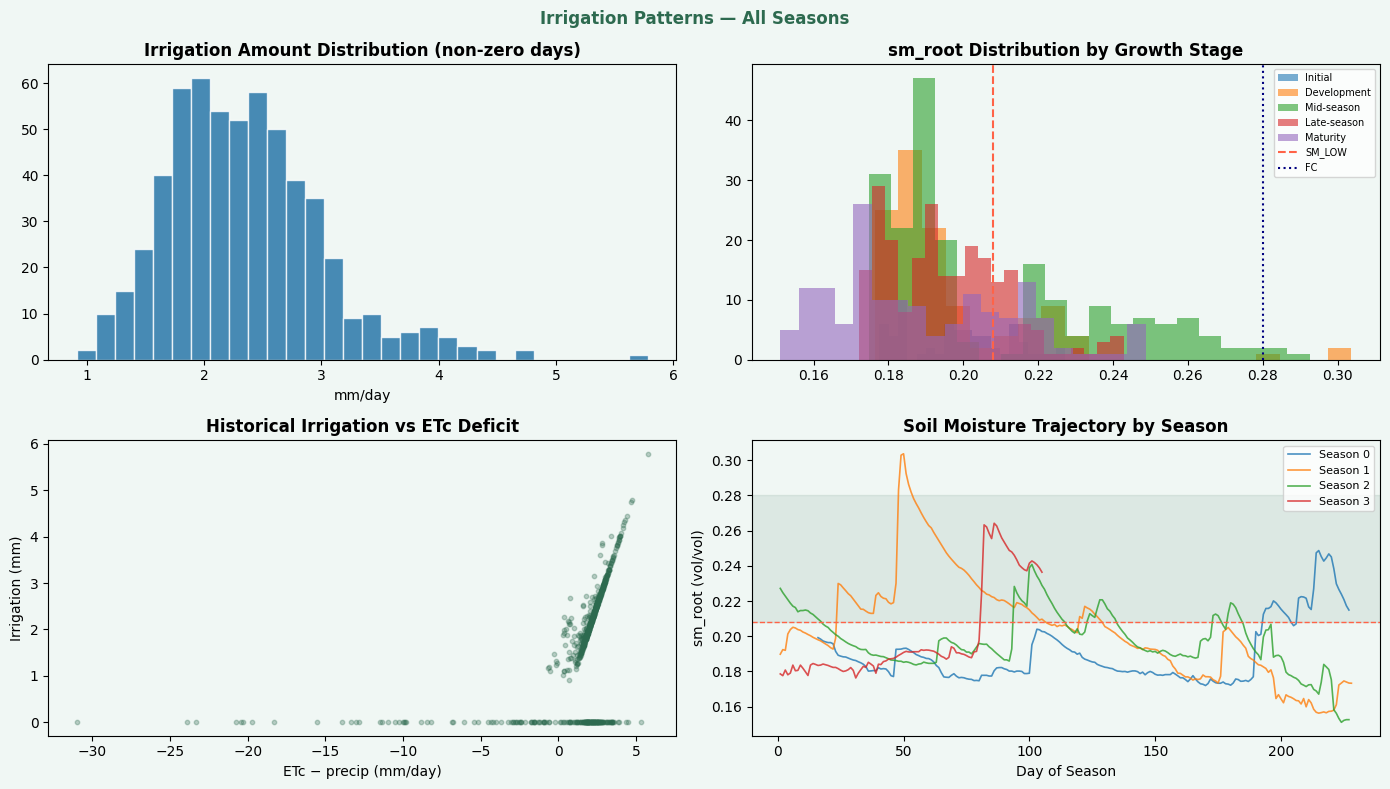

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor='#f0f7f4')
fig.suptitle('Irrigation Patterns — All Seasons', fontsize=12,
             fontweight='bold', color='#2d6a4f')

# Irrigation distribution
axes[0,0].hist(df['irrigation_mm'][df['irrigation_mm']>0], bins=30,
               color='#1d6fa4', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Irrigation Amount Distribution (non-zero days)',
                    fontweight='bold'); axes[0,0].set_xlabel('mm/day')
axes[0,0].set_facecolor('#f0f7f4')

# sm_root distribution by growth stage
for g in range(5):
    subset = df[df['growth_stage']==g]['sm_root']
    axes[0,1].hist(subset, bins=20, alpha=0.6, label=STAGE_NAMES[g])
axes[0,1].axvline(SM_LOW, color='tomato', lw=1.5, ls='--', label='SM_LOW')
axes[0,1].axvline(FC, color='navy', lw=1.5, ls=':', label='FC')
axes[0,1].set_title('sm_root Distribution by Growth Stage', fontweight='bold')
axes[0,1].legend(fontsize=7); axes[0,1].set_facecolor('#f0f7f4')

# Irrigation vs ETc deficit
deficit = df['etc_mm'] - df['precip_mm']
axes[1,0].scatter(deficit, df['irrigation_mm'], alpha=0.3,
                  color='#2d6a4f', s=10)
axes[1,0].set_xlabel('ETc − precip (mm/day)'); axes[1,0].set_ylabel('Irrigation (mm)')
axes[1,0].set_title('Historical Irrigation vs ETc Deficit', fontweight='bold')
axes[1,0].set_facecolor('#f0f7f4')

# Seasonal sm_root pattern
for i, s in enumerate(all_seasons):
    axes[1,1].plot(s['day_of_season'], s['sm_root'],
                   lw=1.2, alpha=0.8, label=f'Season {i}')
axes[1,1].axhspan(SM_LOW, FC, alpha=0.1, color='#2d6a4f')
axes[1,1].axhline(SM_LOW, color='tomato', lw=1, ls='--')
axes[1,1].set_xlabel('Day of Season'); axes[1,1].set_ylabel('sm_root (vol/vol)')
axes[1,1].set_title('Soil Moisture Trajectory by Season', fontweight='bold')
axes[1,1].legend(fontsize=8); axes[1,1].set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('data_analysis.png', dpi=130, bbox_inches='tight')
plt.show()